 # 2.06 — Model Interpretation: What Did the Models Actually Learn?

 2.04, 2.04b, and 2.05 produced the 18 production artifacts and the headline accuracy
 numbers. This notebook is the opposite of those — it doesn't train anything. It loads
 the already-trained models, scores the 2026 holdout one more time, and digs into the
 two questions a number on a chart can't answer:

 1. **What is the model leaning on?** Mean |SHAP| tells me which features carry the
    prediction at each horizon, and the beeswarm shows *how* — does more recent net
    flow push availability up or down, and where does the effect saturate. The logistic
    coefficient read-out does the same for the probability model in plain log-odds.

 2. **Where and when does it fail?** I save every holdout prediction next to its actual
    value and group the error by station, hour, day, season, and weather. That's the map
    of the model's blind spots — and it's exactly what tells me which feature to build
    next (Phase 3 later-enhancements) to buy down RMSE where it's worst.

 A few scope choices up front:
 - **LightGBM is the regressor I interpret** for SHAP and residuals — it's the primary
   production model (2.04). The linear model (2.04b) is the interpretable foil; its story
   is the coefficient signs, which I already covered in 2.02, so I don't re-plot it here.
 - **Logistic Regression is the classifier I interpret** — coefficient table + the
   calibration curve that 2.05 deferred to here (does "70% chance" actually mean 70%).
 - **Everything is scored on 2026**, the untouched holdout. I'm interpreting the models
   on data they never trained on, which is the only honest place to ask "what did they
   learn" — learned patterns that only show up on the training era would be memorization.
 - **SHAP runs on a subsample** (50k rows/horizon), not the full ~2.3M. TreeExplainer is
   exact per row but the beeswarm is a distribution plot — 50k rows render an identical
   picture to 2.3M and keep the whole notebook under an hour instead of several.

In [ ]:
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.linalg
import shap
import statsmodels.api as sm
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore", category=UserWarning)

sys.path.insert(0, str(Path().resolve().parent))
from citibike.config import DB_CONFIG  # noqa: E402
from model_training.feature_prep import (  # noqa: E402
    TARGET_CLASSIFICATION,
    TARGET_REGRESSION,
    build_preprocessor,
    get_X_y,
    load_training_data,
)

 ## Setup

 The horizons, the artifact paths, and the holdout year. Two interpretation-only knobs:
 `SHAP_SAMPLE_N` caps the SHAP subsample, and `REPRESENTATIVE_HORIZON` picks the one
 horizon I drill into for the detailed plots (beeswarm, dependence, the per-station map).
 I use **3hr** as the representative — it's the headline horizon from 2.02, far enough
 out to be a real forecast but close enough that current availability still matters, so
 the SHAP story is the richest. I also pull a long horizon (**24hr**) into the residual
 breakdowns so the short-vs-long contrast is visible.

In [ ]:
HORIZONS = [60, 180, 360, 720, 1440, 2880]
HORIZON_LABELS = {60: "1hr", 180: "3hr", 360: "6hr",
                  720: "12hr", 1440: "24hr", 2880: "multi-day"}

HOLDOUT_YEARS = [2026]              # interpret on the untouched holdout, same as 2.04/2.05
REPRESENTATIVE_HORIZON = 180        # 3hr — the horizon I drill into for beeswarm/dependence/map
LONG_HORIZON = 1440                 # 24hr — the long-horizon foil for residual breakdowns

SHAP_SAMPLE_N  = 50_000             # rows per horizon for SHAP (beeswarm is a distribution)
COEF_SAMPLE_N  = 300_000            # rows for the statsmodels Logit coefficient table
USE_FLOAT32    = True

MODELS_DIR  = Path("../models")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Artifact name patterns, matching what 2.04 / 2.05 saved. (The linear artifacts from
# 2.04b exist too, but this notebook interprets the LightGBM regressor and the logistic
# classifier — see the scope note up top.)
LGBM_ARTIFACT     = lambda h: MODELS_DIR / f"lgbm_regression_{h}min.joblib"
LOGISTIC_ARTIFACT = lambda h: MODELS_DIR / f"logistic_classification_{h}min.joblib"

print(f"Cores: {os.cpu_count()}  |  horizons: {[HORIZON_LABELS[h] for h in HORIZONS]}")
print(f"Holdout: {HOLDOUT_YEARS}  |  representative: {HORIZON_LABELS[REPRESENTATIVE_HORIZON]}"
      f"  |  long foil: {HORIZON_LABELS[LONG_HORIZON]}")

# Confirm every artifact the notebook expects is actually on disk before I start.
missing = [p.name for h in HORIZONS
           for p in (LGBM_ARTIFACT(h), LOGISTIC_ARTIFACT(h))
           if not p.exists()]
if missing:
    print(f"WARNING: missing artifacts -> {missing}")
else:
    print("All LightGBM + Logistic artifacts present.")

Cores: 32  |  horizons: ['1hr', '3hr', '6hr', '12hr', '24hr', 'multi-day']
Holdout: [2026]  |  representative: 3hr  |  long foil: 24hr
All LightGBM + Logistic artifacts present.


 ## Helpers

 Small pieces so the per-horizon work stays readable:
 - `load_holdout` — pulls one horizon's 2026 rows, float32-casts, and hands back the
   full DataFrame (I need `station_id`/`timestamp`/`hour_of_day`/weather for the residual
   grouping, not just the feature matrix). It also returns X for scoring.
 - `shap_values_for` — pulls the fitted preprocessor + LightGBM out of a saved pipeline,
   transforms a subsample, and runs TreeExplainer. Returns the SHAP matrix plus the
   transformed frame and feature names so I can plot beeswarm/dependence directly.

In [ ]:
def load_holdout(horizon, target):
    """Load the 2026 holdout for one horizon. Returns (df, X, y)."""
    df = load_training_data(horizon, years=HOLDOUT_YEARS)
    X, y = get_X_y(df, target)
    if USE_FLOAT32:
        num_cols = X.select_dtypes(include=["float64", "float32"]).columns
        X[num_cols] = X[num_cols].astype("float32")
    return df, X, y


def shap_values_for(pipeline, X, sample_n=SHAP_SAMPLE_N, seed=42):
    """TreeExplainer SHAP values for a saved LightGBM pipeline on a subsample.

    Returns (shap_vals, X_trans_df, feat_names). I pull the already-fitted preprocessor
    and model straight out of the pipeline — no refitting — so the SHAP values describe
    the exact production artifact, transformed feature space and all.
    """
    pre   = pipeline.named_steps["pre"]
    model = pipeline.named_steps["model"]

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=min(sample_n, len(X)), replace=False)
    X_sample = X.iloc[idx]

    X_trans = pre.transform(X_sample)
    feat_names = list(pre.get_feature_names_out())
    X_trans_df = pd.DataFrame(X_trans, columns=feat_names)

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_trans_df)
    return shap_vals, X_trans_df, feat_names

 ## Step 1 — Which features carry the prediction? (mean |SHAP| across horizons)

 The single most useful interpretation view: for each horizon, the average absolute SHAP
 value per feature, which is "how many bikes of prediction does this feature move, on
 average." I compute it for all six horizons and stack them so I can watch the importance
 profile *shift* as the forecast reaches further out. My expectation from the project
 design: short horizons should be dominated by current availability and recent net flow
 (the present basically determines 1hr out), and long horizons should lean harder on the
 demand climatology, time encodings, and weather forecast as the present decays.

In [ ]:
mean_abs_shap = {}   # horizon -> Series(feature -> mean|SHAP|)

for h in HORIZONS:
    label = HORIZON_LABELS[h]
    print(f"SHAP — {label} ...", end=" ", flush=True)
    pipe = joblib.load(LGBM_ARTIFACT(h))
    _, X_ho, _ = load_holdout(h, TARGET_REGRESSION)
    shap_vals, X_trans_df, feat_names = shap_values_for(pipe, X_ho)
    mean_abs_shap[h] = pd.Series(
        np.abs(shap_vals).mean(axis=0), index=feat_names
    ).sort_values(ascending=False)
    print(f"top: {mean_abs_shap[h].index[0]} ({mean_abs_shap[h].iloc[0]:.3f})")
    del pipe, X_ho, shap_vals, X_trans_df

SHAP — 1hr ... top: num_bikes_available (5.968)
SHAP — 3hr ... top: num_bikes_available (5.330)
SHAP — 6hr ... top: num_bikes_available (4.649)
SHAP — 12hr ... top: bikes_12hr_ago (4.293)
SHAP — 24hr ... top: num_bikes_available (4.182)
SHAP — multi-day ... top: num_bikes_available (3.464)


 ### Heatmap — top features by mean |SHAP|, every horizon side by side

 I take the union of the top-12 features at any horizon and lay them out as a heatmap:
 rows are features, columns are horizons, color is mean |SHAP| in bikes. Reading down a
 column tells me what matters at that horizon; reading across a row tells me whether a
 feature's influence grows or fades as the forecast reaches further out. This one image
 is the "how the model re-weights itself with distance" story.

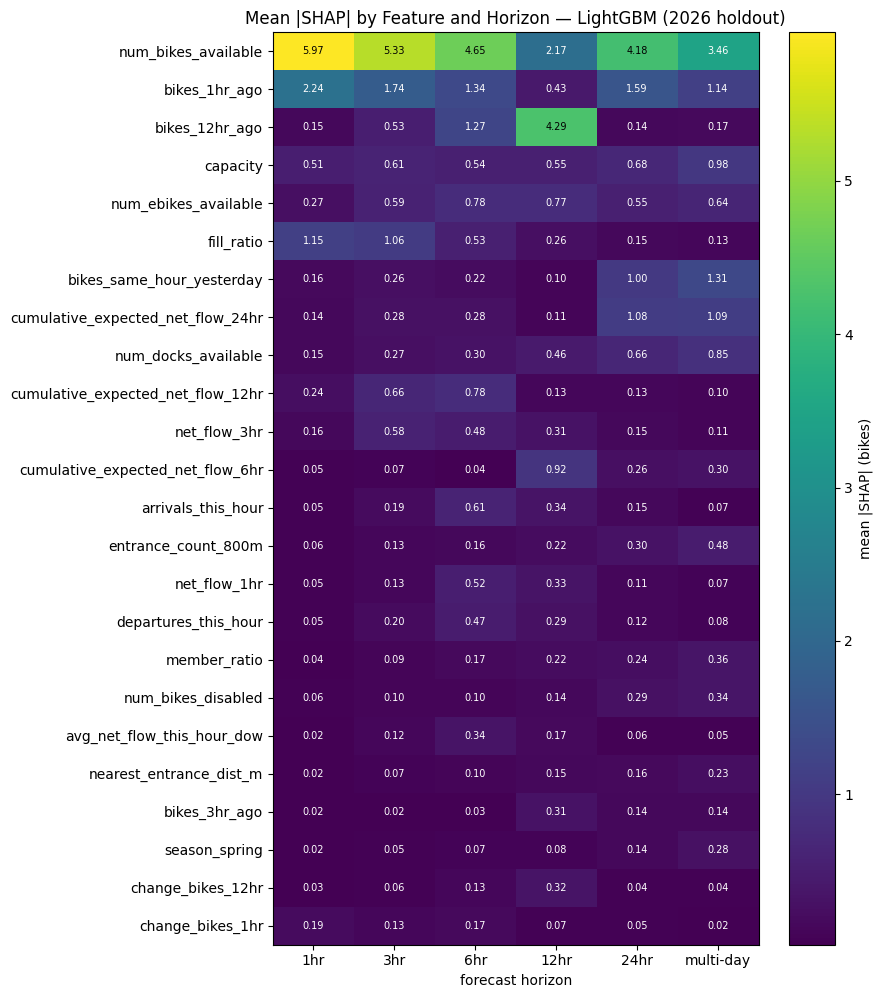

Saved -> reports/figures/2.06_shap_importance_heatmap.png


In [ ]:
top_per_h = {h: mean_abs_shap[h].head(12).index.tolist() for h in HORIZONS}
feat_union = list(dict.fromkeys(f for h in HORIZONS for f in top_per_h[h]))

heat = pd.DataFrame(
    {HORIZON_LABELS[h]: mean_abs_shap[h].reindex(feat_union) for h in HORIZONS},
    index=feat_union,
).fillna(0.0)
# Order rows by overall importance (sum across horizons) so the strongest sit on top.
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, max(6, 0.42 * len(heat))))
im = ax.imshow(heat.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels(heat.index)
ax.set_xlabel("forecast horizon")
ax.set_title("Mean |SHAP| by Feature and Horizon — LightGBM (2026 holdout)")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:.2f}", ha="center", va="center",
                color="white" if heat.values[i, j] < heat.values.max() * 0.6 else "black",
                fontsize=7)
fig.colorbar(im, ax=ax, label="mean |SHAP| (bikes)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.06_shap_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.06_shap_importance_heatmap.png")

 ## Step 2 — How features act: beeswarm + dependence at every horizon up to 24hr

 Mean |SHAP| ranks features but flattens the *direction* — it can't tell me whether high
 fill_ratio pushes the prediction up or down, or whether an effect is linear or saturates.
 The beeswarm restores that: every dot is one station-hour, x-position is the SHAP value
 (left = pushes the predicted count down, right = up), and color is the feature value
 (red = high, blue = low). A clean red-right / blue-left split means "more of this feature
 -> more predicted bikes." I run this for every horizon from 1hr through 24hr so the full
 story of how feature effects shift with distance is on the record in one place.
 The dependence plots show the *shape* of the top-4 features' effects — curvature here is
 the concrete justification for using a gradient booster over a straight line.


SHAP beeswarm + dependence — 1hr ...


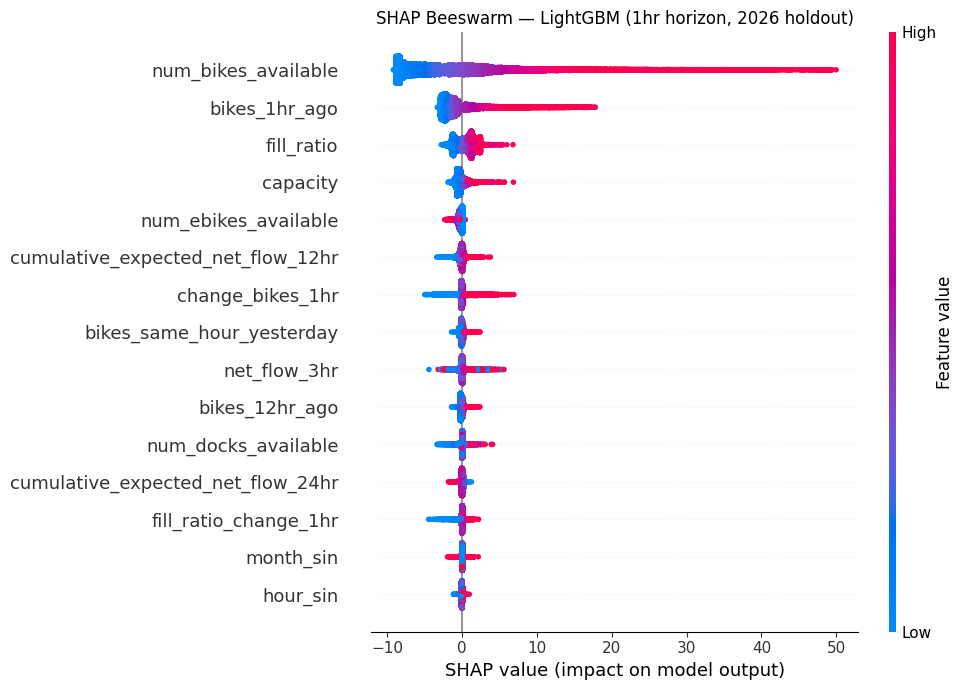

Saved -> 2.06_shap_beeswarm_1hr.png


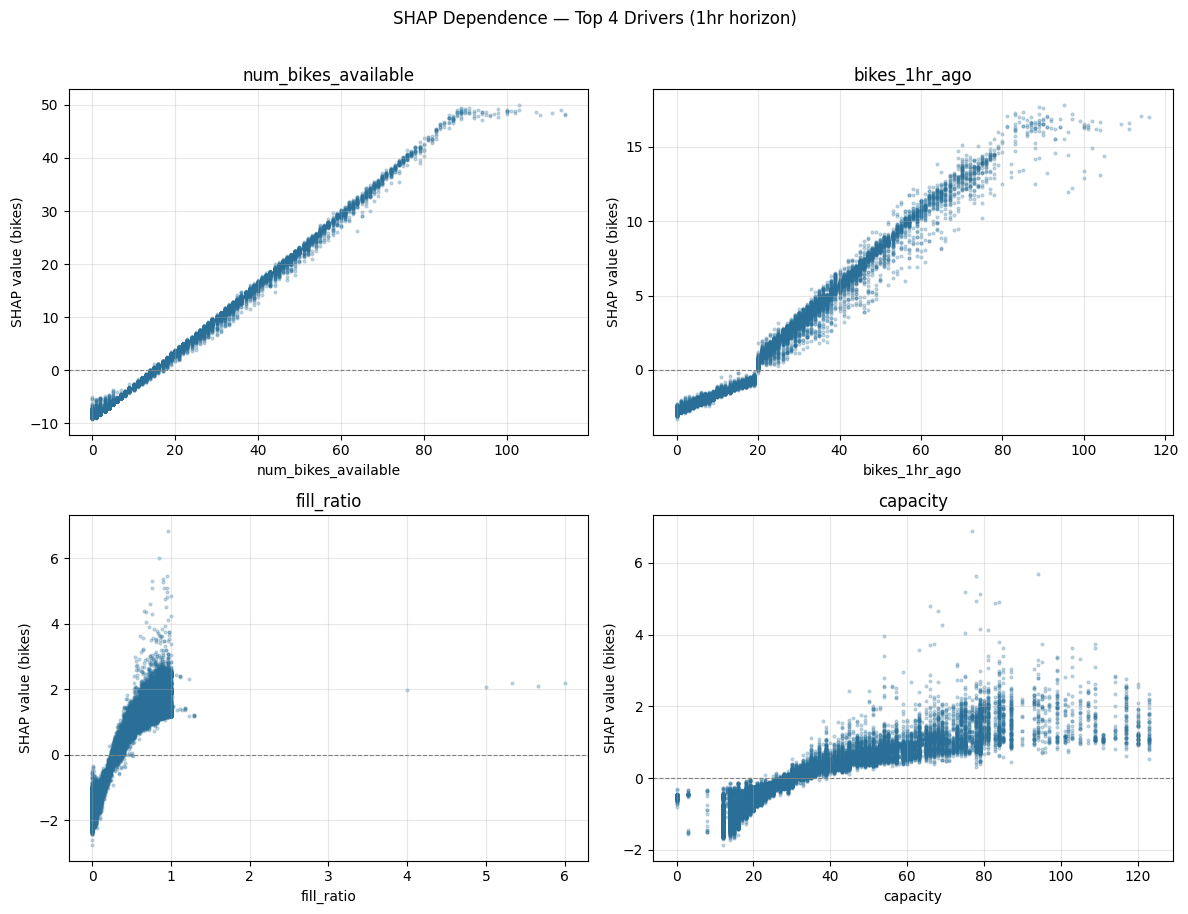

Saved -> 2.06_shap_dependence_top4_1hr.png

SHAP beeswarm + dependence — 3hr ...


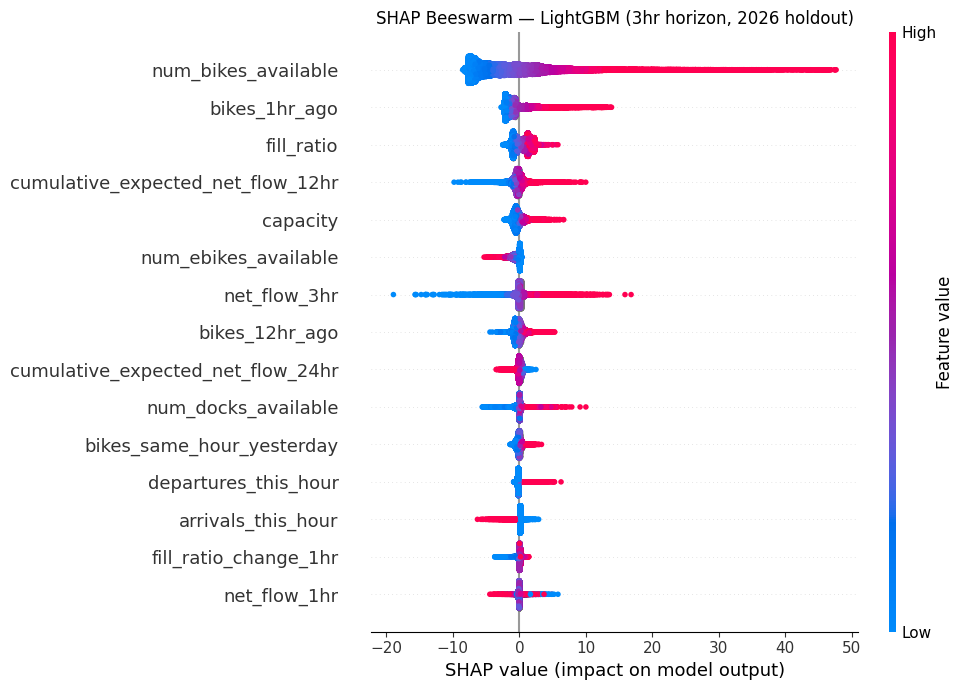

Saved -> 2.06_shap_beeswarm_3hr.png


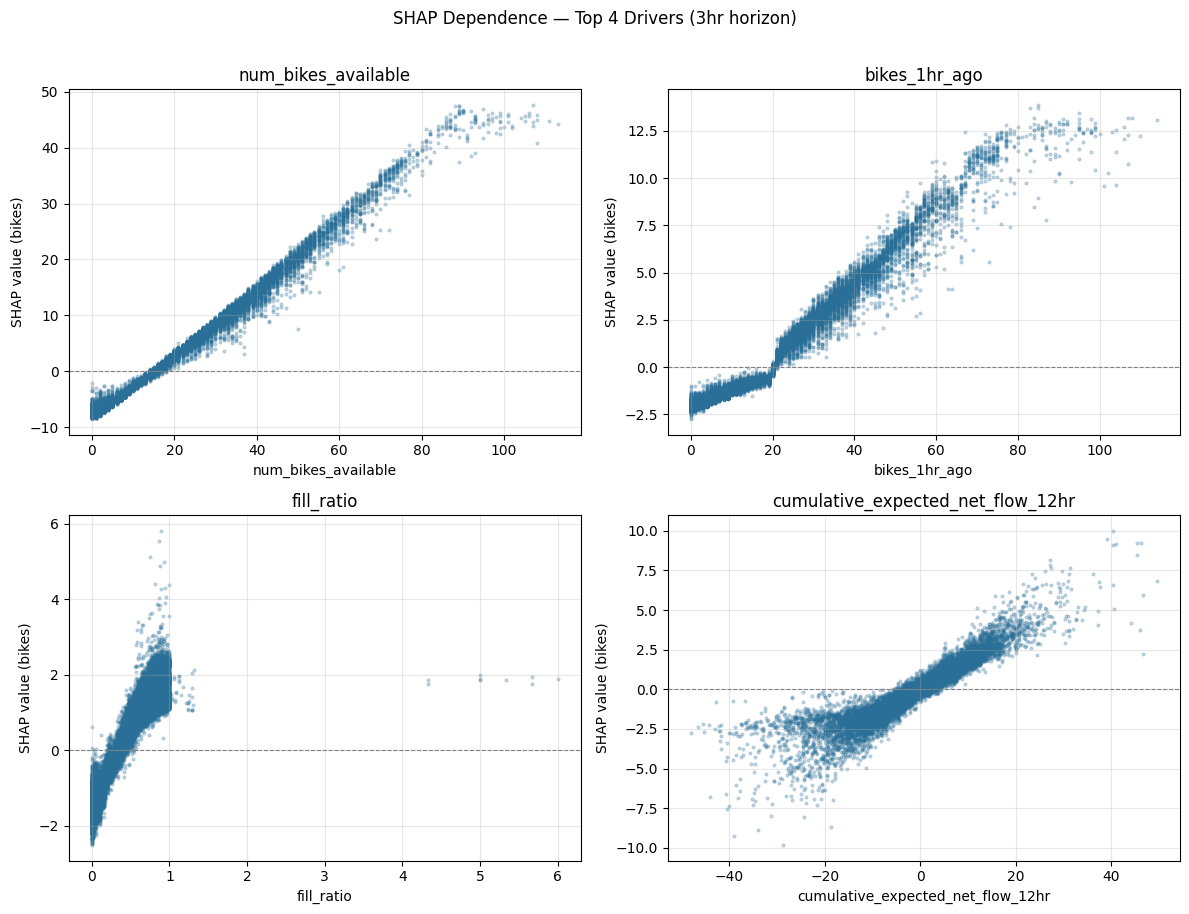

Saved -> 2.06_shap_dependence_top4_3hr.png

SHAP beeswarm + dependence — 6hr ...


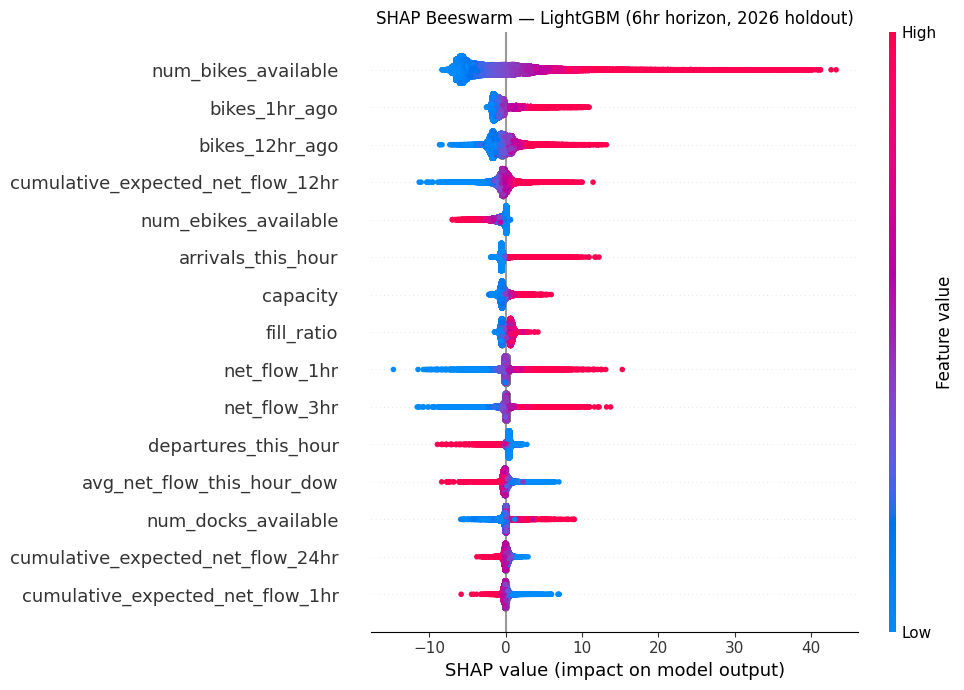

Saved -> 2.06_shap_beeswarm_6hr.png


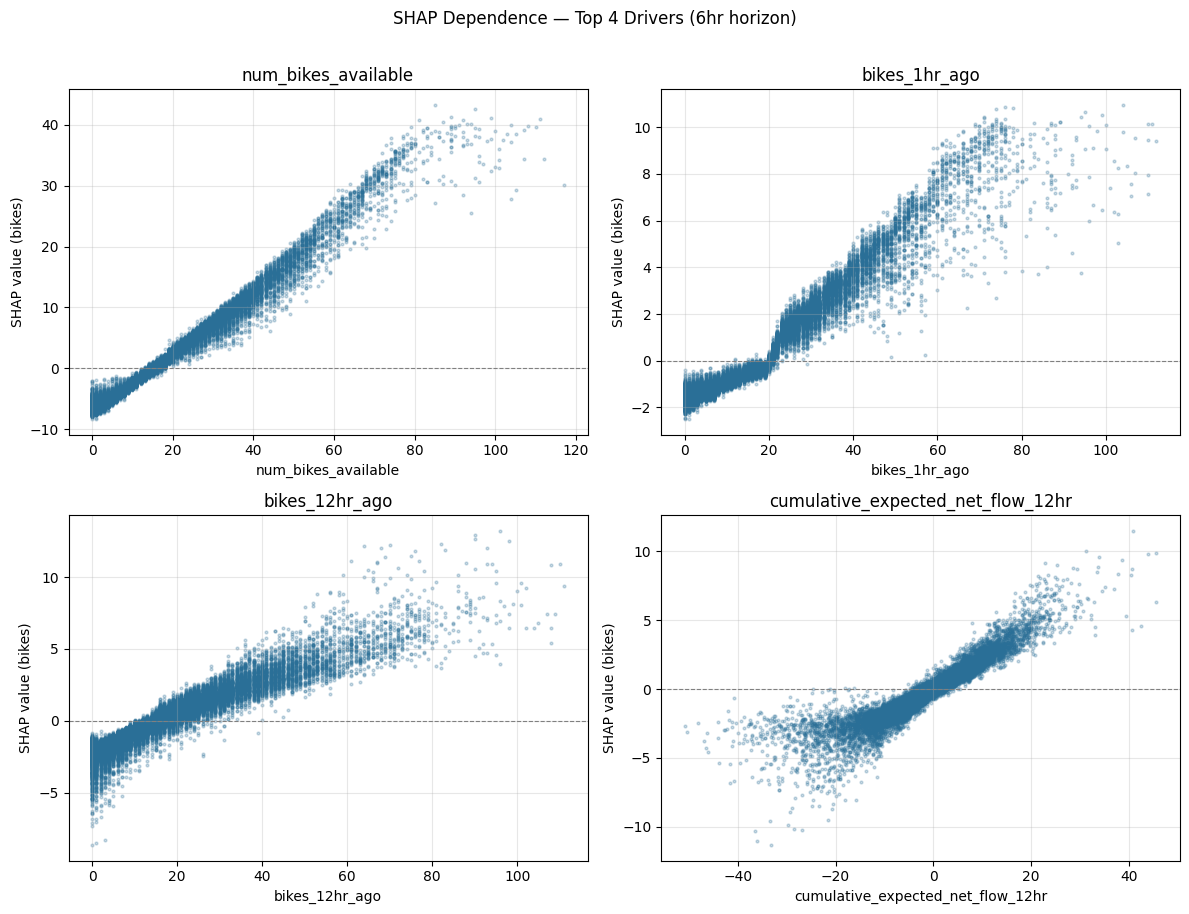

Saved -> 2.06_shap_dependence_top4_6hr.png

SHAP beeswarm + dependence — 12hr ...


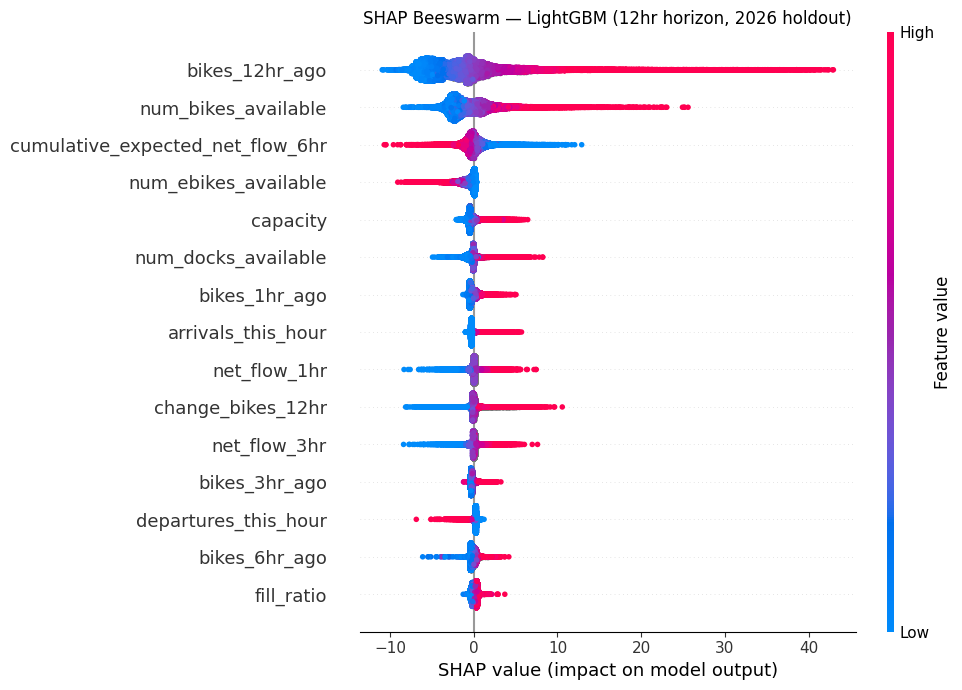

Saved -> 2.06_shap_beeswarm_12hr.png


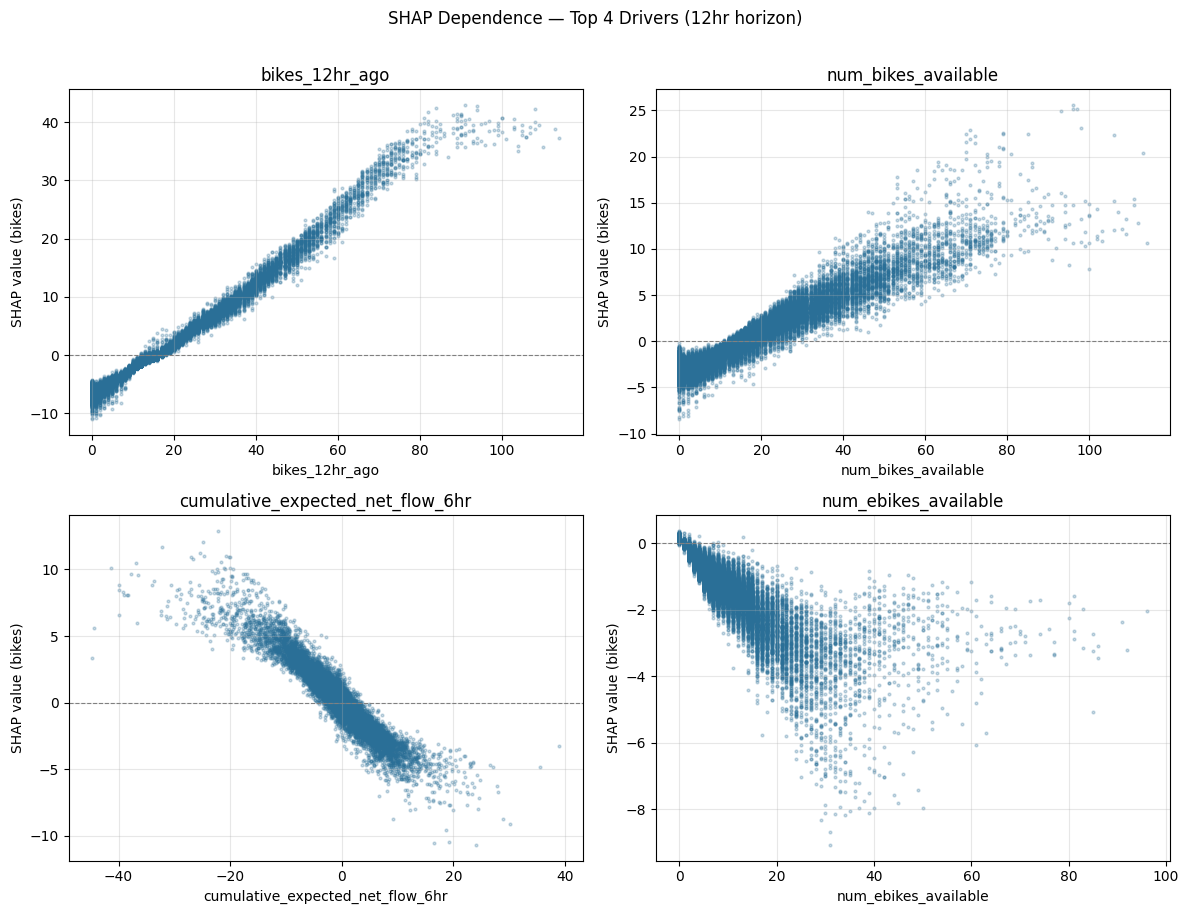

Saved -> 2.06_shap_dependence_top4_12hr.png

SHAP beeswarm + dependence — 24hr ...


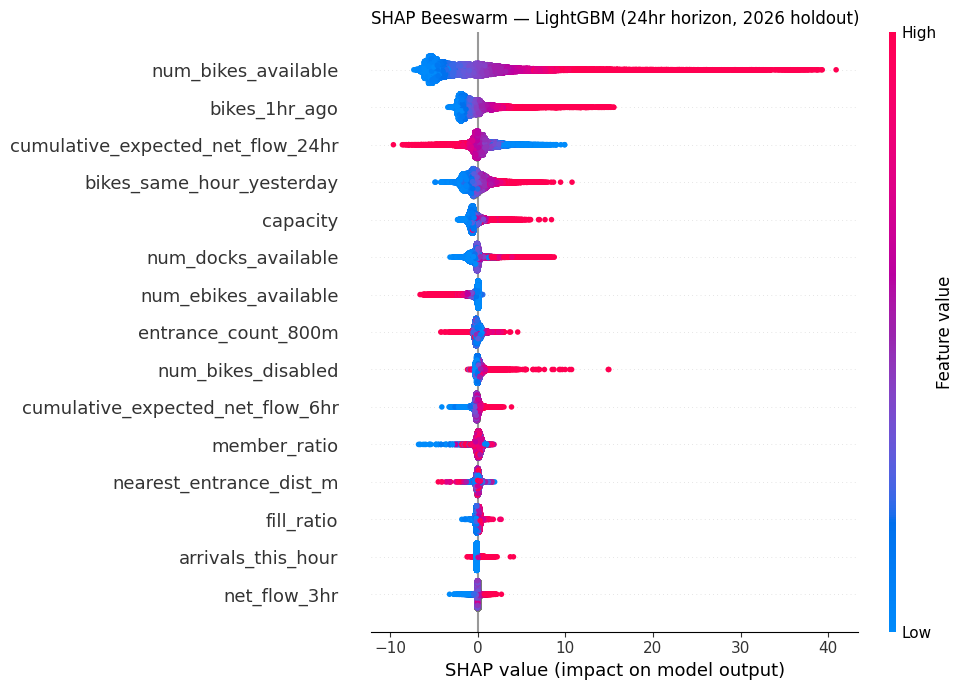

Saved -> 2.06_shap_beeswarm_24hr.png


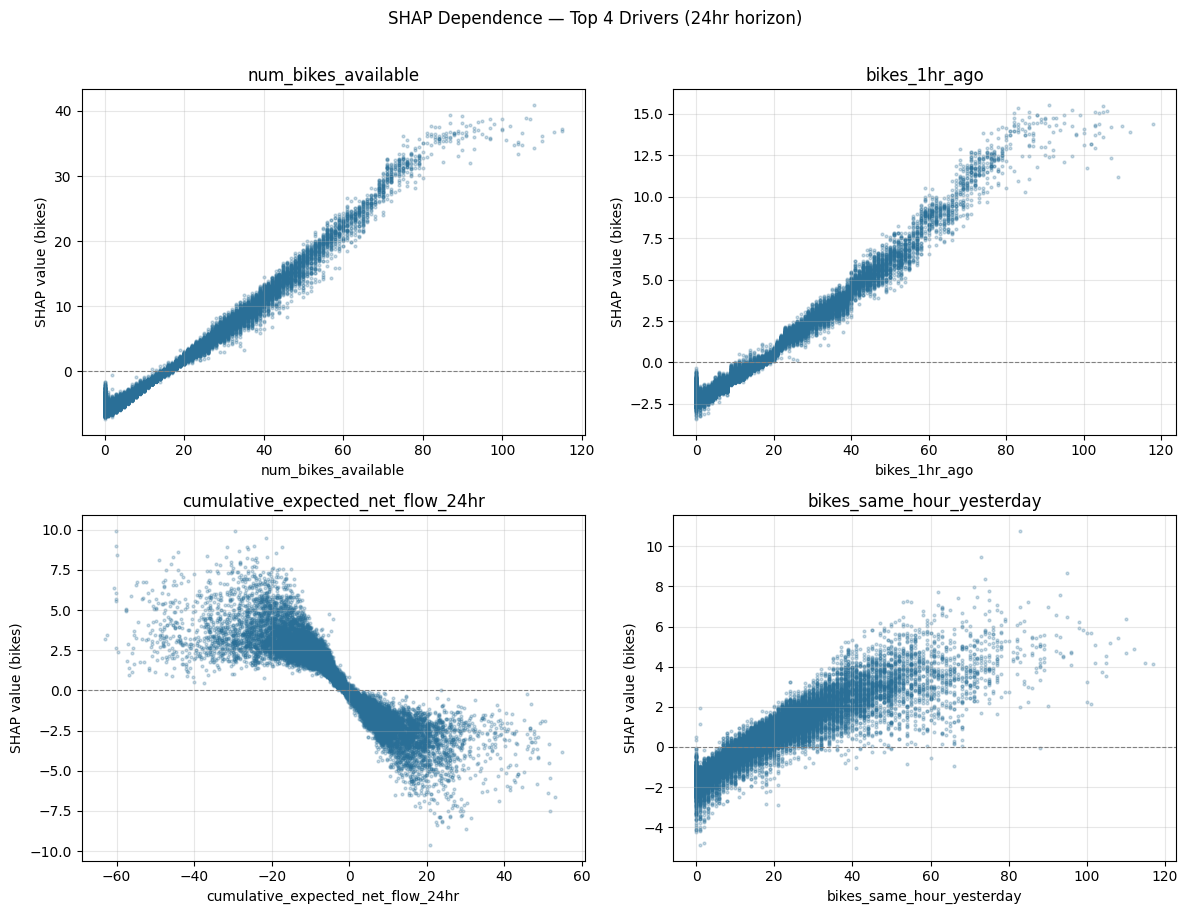

Saved -> 2.06_shap_dependence_top4_24hr.png

All beeswarm + dependence plots saved.


In [ ]:
for h in [60, 180, 360, 720, 1440]:   # 1hr → 24hr
    label = HORIZON_LABELS[h]
    print(f"\nSHAP beeswarm + dependence — {label} ...", flush=True)

    pipe_h = joblib.load(LGBM_ARTIFACT(h))
    _, X_h, _ = load_holdout(h, TARGET_REGRESSION)
    shap_h, X_h_trans, feat_h = shap_values_for(pipe_h, X_h)

    # --- beeswarm ---
    plt.figure()
    shap.summary_plot(shap_h, X_h_trans, max_display=15, show=False, plot_size=(10, 7))
    plt.title(f"SHAP Beeswarm — LightGBM ({label} horizon, 2026 holdout)")
    plt.tight_layout()
    fname = FIGURES_DIR / f"2.06_shap_beeswarm_{label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {fname.name}")

    # --- top-4 dependence ---
    top4_h = mean_abs_shap[h].head(4).index.tolist()
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    for ax, feat in zip(axes.ravel(), top4_h):
        col_idx = feat_h.index(feat)
        ax.scatter(X_h_trans[feat].values, shap_h[:, col_idx],
                   s=4, alpha=0.25, color="#2a6f97")
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_xlabel(feat)
        ax.set_ylabel("SHAP value (bikes)")
        ax.set_title(feat)
        ax.grid(alpha=0.3)
    fig.suptitle(f"SHAP Dependence — Top 4 Drivers ({label} horizon)", y=1.01)
    plt.tight_layout()
    fname = FIGURES_DIR / f"2.06_shap_dependence_top4_{label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {fname.name}")

    del pipe_h, shap_h, X_h_trans

print("\nAll beeswarm + dependence plots saved.")

 ## Step 3 — Logistic Regression coefficient read-out (full driver table per horizon)

 2.05 plotted the top-15 coefficient *chart* per horizon; here I want the complete,
 sortable *table* — every feature with its log-odds coefficient, odds ratio, and
 confidence interval — so the probability model's logic is fully on the record. And I
 want it at **every horizon up to 24hr** (1hr, 3hr, 6hr, 12hr, 24hr), not just 3hr,
 because the whole point of the interpretation is to watch the drivers re-rank as the
 forecast reaches further out — current availability ceding ground to demand climatology
 and time/weather features. (Multi-day is left off this read-out; the coefficient story
 at 24hr already shows the long-horizon regime.)

 Same statsmodels approach as 2.05, wrapped in a helper so I run it identically per
 horizon: fit Logit on a 300k subsample (the full 12M rows make the Hessian singular
 through the change_bikes = change_ebikes + change_classic exact collinearity), and drop
 collinear columns with rank-revealing QR before the fit. The large-n caveat holds —
 every p-value is ~0, so I read coefficient **magnitude and sign**, not significance.

In [ ]:
# Horizons for the coefficient read-out: everything up to and including 24hr.
COEF_HORIZONS = [60, 180, 360, 720, 1440]


def logit_coef_table(horizon, sample_n=COEF_SAMPLE_N, seed=42):
    """Full statsmodels Logit coefficient table for one horizon.

    Returns coef_tbl sorted by |coef| (const dropped). Fits on a subsample with QR
    collinearity pruning so Newton-Raphson doesn't choke on the exact dependencies.
    """
    df = load_training_data(horizon, years=[2019, 2021])
    X, y = get_X_y(df, TARGET_CLASSIFICATION)
    if USE_FLOAT32:
        num_cols = X.select_dtypes(include=["float64", "float32"]).columns
        X[num_cols] = X[num_cols].astype("float32")
    y = y.astype("int8")

    pre   = build_preprocessor("linear")
    X_t   = pre.fit_transform(X).astype(np.float32)
    names = ["const"] + list(pre.get_feature_names_out())

    rng = np.random.default_rng(seed)
    samp = rng.choice(len(X_t), size=min(sample_n, len(X_t)), replace=False)
    X_full = sm.add_constant(X_t[samp].astype(np.float64))
    y_full = y.values[samp].astype(np.float64)

    # QR pivoting drops the collinear columns Newton-Raphson can't invert through.
    R, P = scipy.linalg.qr(X_full, pivoting=True, mode="r")
    tol = max(X_full.shape) * np.abs(R[0, 0]) * np.finfo(np.float64).eps
    rank = int(np.sum(np.abs(np.diag(R)) > tol))
    keep = sorted(P[:rank])
    X_qr = X_full[:, keep]
    names_qr = [names[i] for i in keep]

    logit = sm.Logit(y_full, X_qr).fit(disp=0, maxiter=300)
    ci = logit.conf_int()
    tbl = pd.DataFrame({
        "feature":    names_qr,
        "coef":       np.asarray(logit.params),
        "odds_ratio": np.exp(np.asarray(logit.params)),
        "ci_lower":   ci[:, 0],
        "ci_upper":   ci[:, 1],
    })
    tbl = tbl[tbl["feature"] != "const"].copy()
    tbl = tbl.reindex(tbl["coef"].abs().sort_values(ascending=False).index)
    n_dropped = len(names) - rank
    del df, X, X_t, X_full, X_qr
    return tbl, n_dropped, float(logit.prsquared)

In [ ]:
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 100)

coef_tables = {}   # horizon -> full coefficient table
for h in COEF_HORIZONS:
    label = HORIZON_LABELS[h]
    print(f"\n{'='*70}\nLogit coefficients — {label} horizon\n{'='*70}")
    tbl, n_dropped, pr2 = logit_coef_table(h)
    coef_tables[h] = tbl
    print(f"dropped {n_dropped} collinear cols  |  pseudo R²={pr2:.4f}")
    print(f"\nFull coefficient table ({label}, sorted by |coef|; log-odds of a bike "
          f"being available):")
    print(tbl.to_string(index=False))

    fname = FIGURES_DIR / f"2.06_logit_full_coefficients_{label}.csv"
    tbl.to_csv(fname, index=False)
    print(f"\nSaved -> reports/figures/{fname.name}")


Logit coefficients — 1hr horizon
dropped 5 collinear cols  |  pseudo R²=0.3950

Full coefficient table (1hr, sorted by |coef|; log-odds of a bike being available):
                          feature     coef                  odds_ratio     ci_lower    ci_upper
       avg_arrivals_this_hour_dow  48.3752 1021155522978735718400.0000     -31.3796    128.1300
     avg_departures_this_hour_dow -48.2980                      0.0000    -128.2062     31.6103
       avg_net_flow_this_hour_dow  27.9661          1398055523060.9089     -18.2765     74.2087
                       fill_ratio   4.5693                     96.4735       4.3271      4.8115
                             rain   2.6955                     14.8129     -11.2871     16.6781
                    precipitation  -2.6864                      0.0681     -16.8207     11.4479
              num_bikes_available   1.0530                      2.8662       0.7631      1.3428
          forecast_temperature_2m  -0.6257                      0.5

 ### Coefficients side by side — how the drivers re-rank across horizons

 The per-horizon tables above are the rigorous record; this is the readable summary. I
 pivot the coefficient of each feature across the five horizons into one wide table,
 ordered by overall magnitude, so I can read across a row and watch a driver strengthen
 or fade as the forecast reaches further out. This is the "current availability hands off
 to demand climatology" story in a single grid — the same shape as the SHAP heatmap, but
 in signed log-odds rather than unsigned importance.

In [ ]:
coef_wide = pd.DataFrame(
    {HORIZON_LABELS[h]: coef_tables[h].set_index("feature")["coef"] for h in COEF_HORIZONS}
)
# Order rows by overall magnitude (sum of |coef| across horizons), strongest on top.
coef_wide = coef_wide.reindex(
    coef_wide.abs().sum(axis=1).sort_values(ascending=False).index
)
print("Coefficient (log-odds) by feature and horizon — top 25 by overall magnitude:")
print(coef_wide.head(25).to_string())

coef_wide.to_csv(FIGURES_DIR / "2.06_logit_coefficients_by_horizon.csv")
print("\nSaved -> reports/figures/2.06_logit_coefficients_by_horizon.csv")

Coefficient (log-odds) by feature and horizon — top 25 by overall magnitude:
                                       1hr       3hr       6hr     12hr     24hr
feature                                                                         
precipitation                      -2.6864 -512.8520 -130.2601  12.4451  26.9173
rain                                2.6955  506.9137  128.6265 -12.3177 -26.6800
avg_arrivals_this_hour_dow         48.3752   -6.1777    6.7115 -35.1608  34.4840
avg_departures_this_hour_dow      -48.2980    6.4166   -6.4619  34.9043 -34.4485
snowfall                            0.3779   76.6805   20.3462  -1.7819  -3.6595
forecast_precipitation              0.3870   49.8281  -19.2687  17.2421      NaN
forecast_rain                      -0.3644  -49.6505   19.2377 -17.1694   0.0745
avg_net_flow_this_hour_dow         27.9661   -3.9700    3.6714 -20.7324  20.0608
fill_ratio                          4.5693    2.6156    1.5777  -0.2390   1.6142
forecast_snowfall               

 ## Step 4 — Calibration curve (does "70% chance" mean 70%?)

 This is the check 2.05 explicitly deferred to here. AUC says the classifier *ranks*
 available vs empty stations well, but the app sells a **probability** — "73% chance a
 bike is there." A calibration curve tests that promise: bin predictions by stated
 probability, then plot the actual fraction available in each bin against the stated
 probability. A model on the diagonal is perfectly calibrated; below the diagonal it's
 overconfident, above it's underconfident. I overlay all six horizons — I expect the
 short horizons to hug the diagonal and the long horizons to drift, since further-out
 probabilities are honestly mushier.

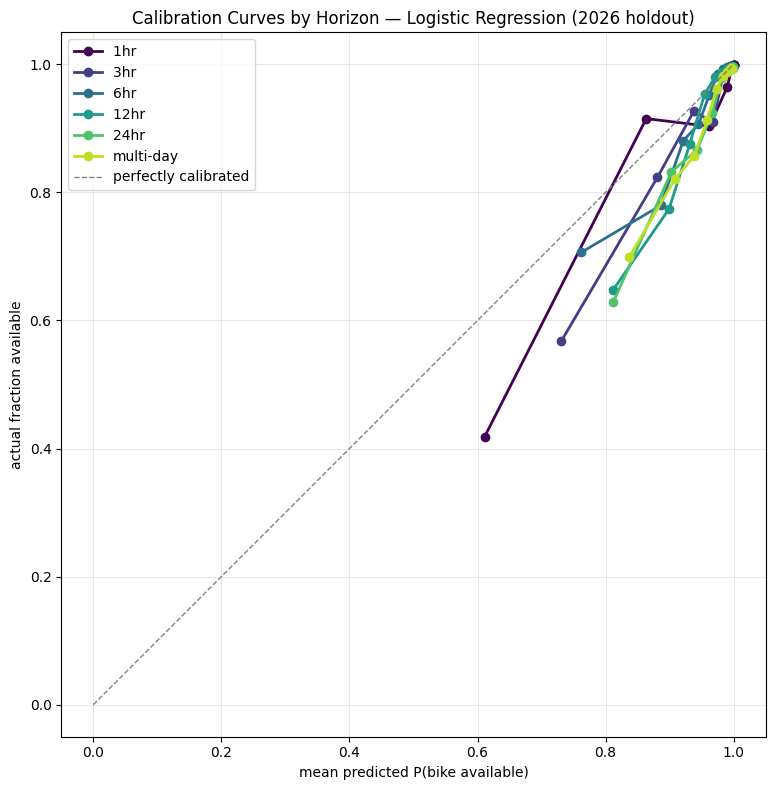

Saved -> reports/figures/2.06_calibration_by_horizon.png

Mean absolute calibration error by horizon (lower = more honest probabilities):
  horizon  mean_abs_calib_error
      1hr                0.0334
      3hr                0.0297
      6hr                0.0277
     12hr                0.0371
     24hr                0.0388
multi-day                0.0375


In [ ]:
plt.figure(figsize=(8, 8))
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(HORIZONS)))
calib_summary = []

for color, h in zip(cmap, HORIZONS):
    pipe = joblib.load(LOGISTIC_ARTIFACT(h))
    _, X_ho, y_ho = load_holdout(h, TARGET_CLASSIFICATION)
    y_ho = y_ho.astype("int8")
    proba = pipe.predict_proba(X_ho)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_ho, proba, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", color=color, lw=2,
             label=f"{HORIZON_LABELS[h]:<9}")
    # Calibration error: mean gap between stated and actual across the bins.
    calib_summary.append({
        "horizon": HORIZON_LABELS[h],
        "mean_abs_calib_error": float(np.mean(np.abs(frac_pos - mean_pred))),
    })
    del pipe, X_ho, y_ho, proba

plt.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="perfectly calibrated")
plt.xlabel("mean predicted P(bike available)")
plt.ylabel("actual fraction available")
plt.title("Calibration Curves by Horizon — Logistic Regression (2026 holdout)")
plt.legend(loc="upper left", fontsize=10)
plt.grid(alpha=0.3)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.06_calibration_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.06_calibration_by_horizon.png")

print("\nMean absolute calibration error by horizon (lower = more honest probabilities):")
print(pd.DataFrame(calib_summary).to_string(index=False))

 ## Step 5 — Residual analysis: where and when does the regressor fail?

 Now the blind-spot map. I score the LightGBM regressor on the full 2026 holdout for
 every horizon and keep a lean residual frame — `station_id`, `timestamp`, horizon,
 predicted, actual, abs_error, plus the grouping columns (hour, day-of-week, season,
 temperature, precipitation). Grouping the absolute error by each of those tells me the
 *conditions* under which the forecast is worst, which is the direct input to "what
 feature do I build next." I keep all six horizons in the frame for the by-horizon view,
 then drill into 3hr (representative) and 24hr (long foil) for the detailed cuts.

In [ ]:
resid_parts = []
keep_cols = ["station_id", "timestamp", "hour_of_day", "day_of_week",
             "season", "temperature_2m", "precipitation"]

for h in HORIZONS:
    label = HORIZON_LABELS[h]
    print(f"Scoring residuals — {label} ...", end=" ", flush=True)
    pipe = joblib.load(LGBM_ARTIFACT(h))
    df_ho, X_ho, y_ho = load_holdout(h, TARGET_REGRESSION)
    preds = pipe.predict(X_ho)

    part = df_ho[keep_cols].copy()
    part["horizon"]   = label
    part["predicted"] = preds
    part["actual"]    = y_ho.values
    part["abs_error"] = np.abs(preds - y_ho.values)
    resid_parts.append(part)
    print(f"MAE {part['abs_error'].mean():.3f}  n {len(part):,}")
    del pipe, df_ho, X_ho, y_ho, preds

resid = pd.concat(resid_parts, ignore_index=True)
del resid_parts
print(f"\nResidual frame: {len(resid):,} rows across {resid['horizon'].nunique()} horizons")

Scoring residuals — 1hr ... MAE 1.678  n 2,382,240
Scoring residuals — 3hr ... MAE 3.084  n 2,365,366
Scoring residuals — 6hr ... MAE 4.325  n 2,338,855
Scoring residuals — 12hr ... MAE 4.985  n 2,295,470
Scoring residuals — 24hr ... MAE 5.159  n 2,235,179
Scoring residuals — multi-day ... MAE 6.125  n 2,177,177

Residual frame: 13,794,287 rows across 6 horizons


 ### Worst stations by mean absolute error (3hr)

 Which physical stations does the model miss most? I rank the 3hr residuals by per-station
 mean abs error (requiring a minimum row count so a single noisy station-hour can't top the
 list). I expect the worst offenders to be large-capacity, high-churn stations — the ones
 where rebalancing trucks move 20+ bikes at once, an event the features don't see. That
 pattern is the argument for the rebalancing-signal feature still on the backlog.

In [ ]:
MIN_ROWS = 200
rep_label = HORIZON_LABELS[REPRESENTATIVE_HORIZON]
r3 = resid[resid["horizon"] == rep_label]

by_station = (
    r3.groupby("station_id")
      .agg(mean_abs_error=("abs_error", "mean"),
           n=("abs_error", "size"),
           mean_actual=("actual", "mean"))
      .query("n >= @MIN_ROWS")
      .sort_values("mean_abs_error", ascending=False)
)
print(f"Worst 15 stations by mean abs error ({rep_label}, >= {MIN_ROWS} rows):")
print(by_station.head(15).to_string())
print(f"\nBest 5 stations (model nails these):")
print(by_station.tail(5).to_string())

by_station.to_csv(FIGURES_DIR / "2.06_residuals_by_station_3hr.csv")
print("\nSaved -> reports/figures/2.06_residuals_by_station_3hr.csv")

Worst 15 stations by mean abs error (3hr, >= 200 rows):
                                      mean_abs_error    n  mean_actual
station_id                                                            
1960020817312746312                          19.4080  982      80.8024
66dc7de9-0aca-11e7-82f6-3863bb44ef7c         18.5143  982      47.8656
daefc84c-1b16-4220-8e1f-10ea4866fdc7         18.0673  982      30.7230
66dc1beb-0aca-11e7-82f6-3863bb44ef7c         17.0306  982      63.0295
66dc7659-0aca-11e7-82f6-3863bb44ef7c         15.5412  982      49.8870
66dc3f08-0aca-11e7-82f6-3863bb44ef7c         14.9044  982      42.5611
66dc7f02-0aca-11e7-82f6-3863bb44ef7c         14.5739  982      26.2546
66dbc982-0aca-11e7-82f6-3863bb44ef7c         14.4384  982      27.7637
116dbc02-a3c1-4b65-9f73-2a09a2aa1379         14.1482  982      38.3717
c37931bb-8571-4671-a9a8-f3cf23897680         13.8447  982      53.1375
66dbe4db-0aca-11e7-82f6-3863bb44ef7c         13.7700  982      30.2332
66ddbd20-0aca-11e7-82

 ### Error by hour of day and season — 3hr vs 24hr

 When is the model worst? I cut mean abs error by hour-of-day and by season, for the
 short (3hr) and long (24hr) horizons together. The rush-hour peaks are where I expect
 the short-horizon model to struggle — bikes move fastest at 8am/6pm, so a 3hr forecast
 is chasing the steepest part of the curve. The seasonal cut is a sanity check on whether
 the model handles summer tourist demand differently from winter.

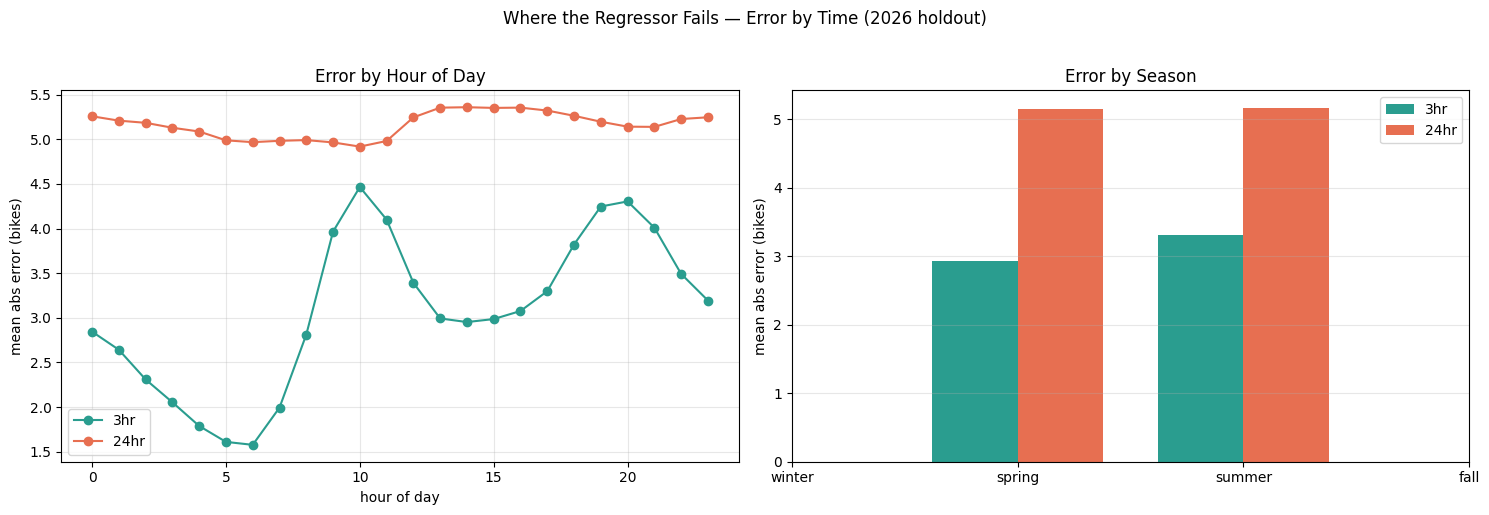

Saved -> reports/figures/2.06_error_by_time.png


In [ ]:
r24 = resid[resid["horizon"] == HORIZON_LABELS[LONG_HORIZON]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hour-of-day
for label, rr, c in [(rep_label, r3, "#2a9d8f"),
                     (HORIZON_LABELS[LONG_HORIZON], r24, "#e76f51")]:
    by_hour = rr.groupby("hour_of_day")["abs_error"].mean()
    axes[0].plot(by_hour.index, by_hour.values, marker="o", color=c, label=label)
axes[0].set_xlabel("hour of day")
axes[0].set_ylabel("mean abs error (bikes)")
axes[0].set_title("Error by Hour of Day")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Season
season_order = ["winter", "spring", "summer", "fall"]
width = 0.38
xs = np.arange(len(season_order))
for off, (label, rr, c) in zip(
    [-width / 2, width / 2],
    [(rep_label, r3, "#2a9d8f"), (HORIZON_LABELS[LONG_HORIZON], r24, "#e76f51")],
):
    by_season = rr.groupby("season")["abs_error"].mean().reindex(season_order)
    axes[1].bar(xs + off, by_season.values, width, color=c, label=label)
axes[1].set_xticks(xs)
axes[1].set_xticklabels(season_order)
axes[1].set_ylabel("mean abs error (bikes)")
axes[1].set_title("Error by Season")
axes[1].grid(alpha=0.3, axis="y")
axes[1].legend()

fig.suptitle("Where the Regressor Fails — Error by Time (2026 holdout)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.06_error_by_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.06_error_by_time.png")

 ### Error by weather — does rain or cold throw the model off?

 Weather is a forward-looking feature (the forecast variables), so a clean test is whether
 error spikes in conditions the model should already see coming. I bin the 3hr residuals
 by temperature and by a simple rain/no-rain split. If error is flat across weather, the
 forecast features are doing their job; if it spikes on rainy or freezing hours, that's a
 signal those conditions shift demand in ways the current features don't fully capture.

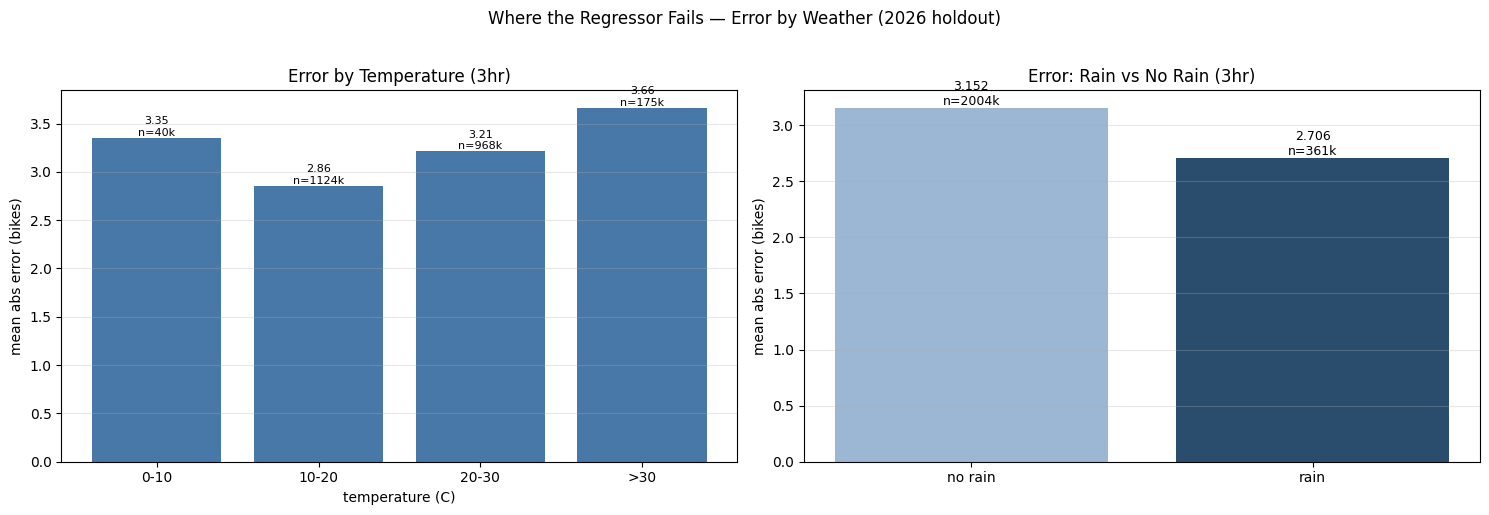

Saved -> reports/figures/2.06_error_by_weather.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Temperature bins (Celsius).
temp_bins = [-20, 0, 10, 20, 30, 50]
temp_labels = ["<0", "0-10", "10-20", "20-30", ">30"]
r3 = r3.assign(temp_bin=pd.cut(r3["temperature_2m"], bins=temp_bins, labels=temp_labels))
by_temp = r3.groupby("temp_bin", observed=True)["abs_error"].agg(["mean", "size"])
axes[0].bar(by_temp.index.astype(str), by_temp["mean"], color="#4878a8")
for i, (m, n) in enumerate(zip(by_temp["mean"], by_temp["size"])):
    axes[0].text(i, m, f"{m:.2f}\nn={n//1000}k", ha="center", va="bottom", fontsize=8)
axes[0].set_xlabel("temperature (C)")
axes[0].set_ylabel("mean abs error (bikes)")
axes[0].set_title(f"Error by Temperature ({rep_label})")
axes[0].grid(alpha=0.3, axis="y")

# Rain vs no rain.
r3 = r3.assign(is_raining=np.where(r3["precipitation"].fillna(0) > 0, "rain", "no rain"))
by_rain = r3.groupby("is_raining")["abs_error"].agg(["mean", "size"])
axes[1].bar(by_rain.index.astype(str), by_rain["mean"], color=["#9bb7d4", "#2a4d6e"])
for i, (m, n) in enumerate(zip(by_rain["mean"], by_rain["size"])):
    axes[1].text(i, m, f"{m:.3f}\nn={n//1000}k", ha="center", va="bottom", fontsize=9)
axes[1].set_ylabel("mean abs error (bikes)")
axes[1].set_title(f"Error: Rain vs No Rain ({rep_label})")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Where the Regressor Fails — Error by Weather (2026 holdout)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.06_error_by_weather.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.06_error_by_weather.png")

 ## Step 6 — Geographic map of per-station error, all horizons up to 24hr

 The residual table tells me *which* stations are hard; a map tells me *where* they are,
 which is the part that suggests a cause. I run this for every horizon from 1hr through
 24hr on a shared color scale so the panels are directly comparable — if the same stations
 are hard at every horizon the issue is station-level (capacity, rebalancing patterns); if
 the hard stations shift, that's a horizon-specific spatial signal. A cluster in Midtown or
 along the waterfront would argue for the neighbor-availability and rail-proximity features
 still on the backlog.

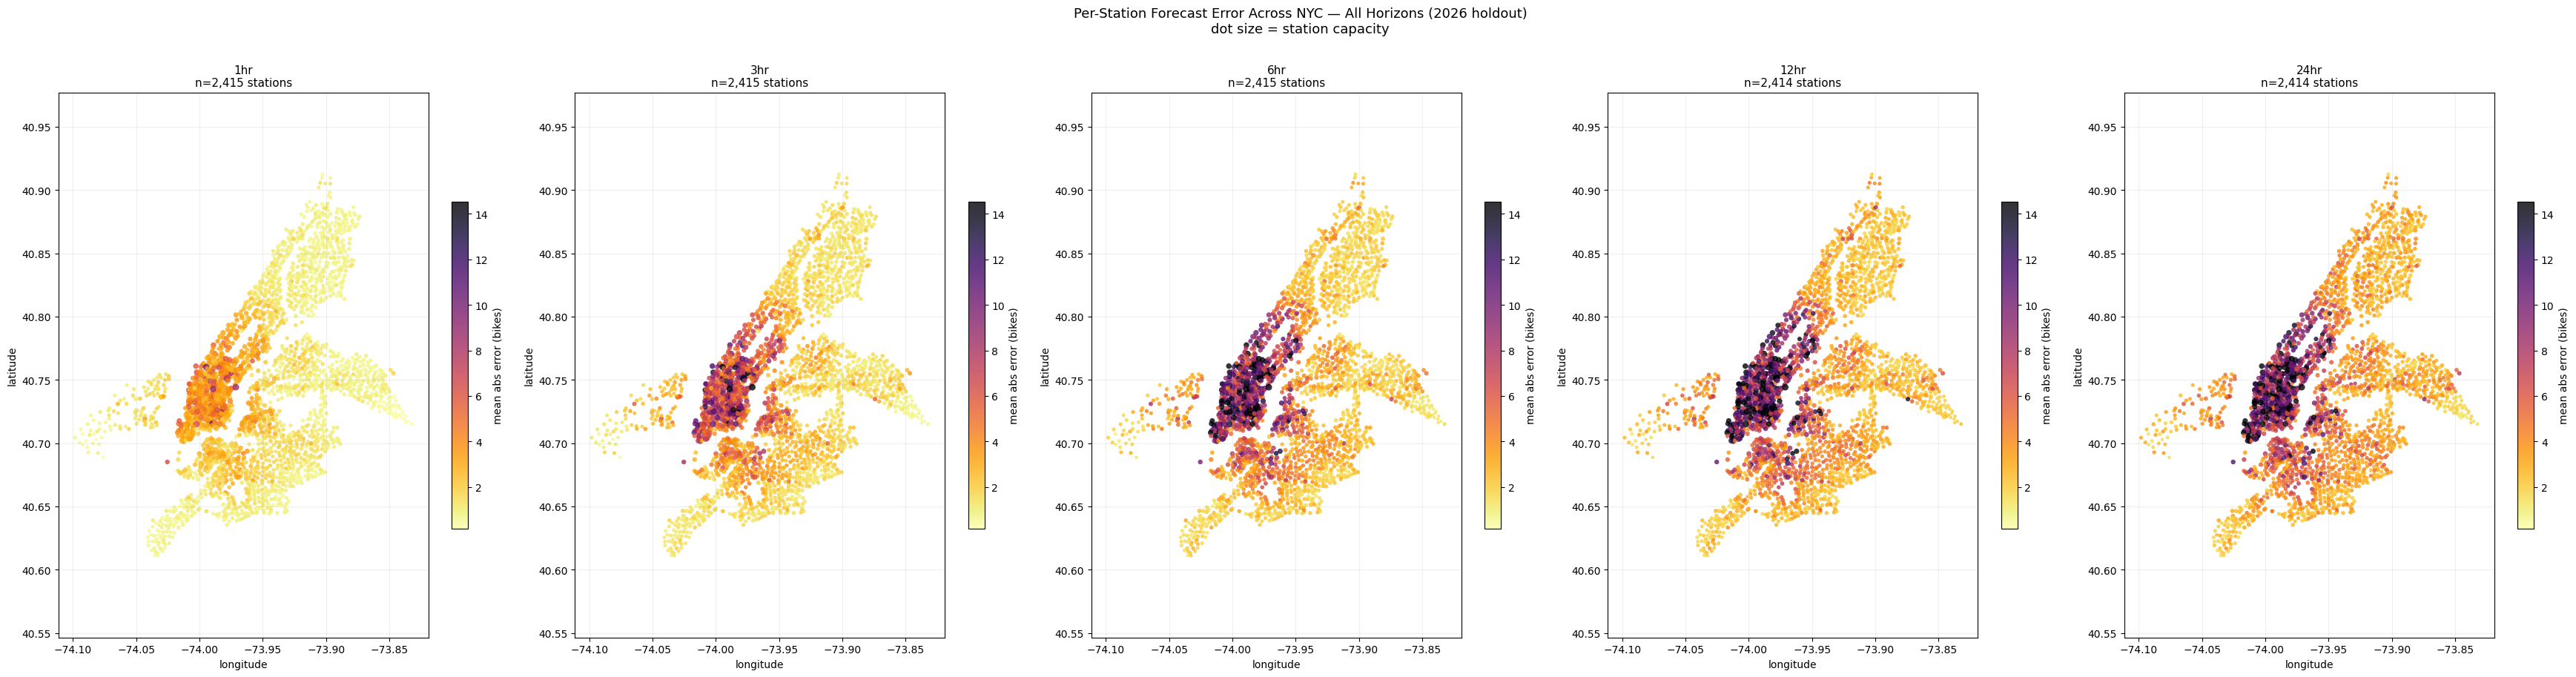

Saved -> reports/figures/2.06_error_map_all_horizons.png


In [ ]:
import psycopg2  # noqa: E402

with psycopg2.connect(**DB_CONFIG) as conn:
    stations = pd.read_sql(
        "SELECT station_id, lat, lon, capacity FROM station_information", conn
    )

map_horizons = [60, 180, 360, 720, 1440]   # 1hr → 24hr; multi-day excluded
fig, axes = plt.subplots(1, len(map_horizons), figsize=(7 * len(map_horizons), 9))

vmin = resid["abs_error"].quantile(0.05)
vmax = resid["abs_error"].quantile(0.95)

for ax, h in zip(axes, map_horizons):
    label = HORIZON_LABELS[h]
    rh = resid[resid["horizon"] == label]
    by_st = (
        rh.groupby("station_id")
          .agg(mean_abs_error=("abs_error", "mean"), n=("abs_error", "size"))
          .query("n >= 200")
    )
    geo_h = by_st.reset_index().merge(stations, on="station_id", how="inner")
    sc = ax.scatter(
        geo_h["lon"], geo_h["lat"],
        c=geo_h["mean_abs_error"],
        s=10 + geo_h["capacity"].fillna(0) * 0.25,
        cmap="inferno_r", alpha=0.8, edgecolors="none",
        vmin=vmin, vmax=vmax,
    )
    ax.set_title(f"{label}\nn={len(geo_h):,} stations", fontsize=11)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.grid(alpha=0.2)
    ax.set_aspect("equal", adjustable="datalim")
    plt.colorbar(sc, ax=ax, label="mean abs error (bikes)", shrink=0.6)

fig.suptitle("Per-Station Forecast Error Across NYC — All Horizons (2026 holdout)\n"
             "dot size = station capacity", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.06_error_map_all_horizons.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.06_error_map_all_horizons.png")

 ## Conclusion

 *(Fill in after running — these are the questions the run answers.)*

 **What the models learned (SHAP + coefficients):**
 - At the short horizons, did current availability + recent net flow dominate as expected,
   and does the importance heatmap show those handing off to demand climatology / time /
   weather-forecast features as the horizon stretches to multi-day? Quote the top-3 at 1hr
   vs multi-day.
 - Did the dependence plots show real curvature (saturation near full/empty, thresholds on
   net flow)? That curvature is the concrete justification for LightGBM over Linear at the
   short horizons — note where the line would have missed it.
 - From the logistic table: the strongest log-odds drivers of availability, with the usual
   caveat that the collinear demand family inflates individual coefficients (read SHAP, not
   coefficients, as the importance story).

 **Are the probabilities honest (calibration):**
 - Did the short horizons hug the diagonal and the long horizons drift, and in which
   direction (over- or under-confident)? Quote the mean abs calibration error per horizon.
   If a horizon is materially off, that's a flag to add a calibration step (Platt/isotonic)
   before serving probabilities to users.

 **Where the model fails (residuals) — the feature backlog driver:**
 - Are the worst stations the large-capacity, high-churn ones? If so, that's the case for
   the unbuilt `rebalancing_signal` / `time_since_last_rebalancing` features.
 - Do the rush-hour error peaks confirm the short-horizon model chases the steepest demand?
   That points at `bikes_same_hour_same_weekday_4wk_avg` (still 100% NULL) as the highest-
   value add for 12hr+.
 - Does error spike in rain/cold, or stay flat? Flat = the forecast-weather features work;
   a spike = weather shifts demand in ways the current features miss.
 - Does the error map show spatial clustering? Clustering argues for the neighbor-
   availability (`avg_availability_5_nearest_stations`) and rail-proximity features.

 Whatever the run shows, the ranked list of failure conditions here *is* the prioritized
 input to the Phase 3 later-enhancements list — build the feature that targets the biggest
 error bucket first, rebuild training_features with the additive patch pattern, and re-run
 2.04 to measure the RMSE it bought back.